[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yogevsim-bgu/franck-hertz/blob/main/Frank_Hertz_Exp4.ipynb)

# Experiment 4: Frank-Hertz Neon – First Excitation Energy of Neon

Analysis of the Frank-Hertz I–V characteristic in a neon-filled tube at room temperature.
Five I–V curves are acquired at retarding voltages $V_r \in \{2, 4, 6, 8, 10\}$ V.
The best measurement is selected for full analysis, and the first excitation energy of neon is
extracted from a linear fit to the positions of successive current minima.

## Required Installs and Imports

In [1]:
!pip install -q matplotlib iminuit scikit-learn

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
# general python packages for classes, warning ,etc.
from abc import ABC, abstractmethod
from typing import Annotated
import warnings

# numpy for numeric calcualtion
import numpy as np
import seaborn as sns
# matplotlib for plotting
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

# iminuit as the minimizer
from iminuit import Minuit, describe
from iminuit.util import make_func_code, describe

# sklearn for goodness estimation methods
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from scipy.stats.distributions import chi2 #this is for chi2 statistics there is likely a way to calculate (in particular p-value) from numpy or sklearn ...
from scipy.signal import find_peaks, savgol_filter

%matplotlib inline
warnings.simplefilter("ignore")

## Class Definitions

We define here a base regressor class that has the responsibility to provide iminuit with the cost function value. It is also responsible to produce the goodness estimation and to plot the result via the show method.

All changes to the way the plots are presented should be modified here.

In [3]:
class Regressor(ABC):
    """
    Abstract base class for regressors compatible with Iminuit.
    To edit the plotting of the graph, edit the show method.
    """

    @abstractmethod
    def __init__(self, model : callable, x : list, y: list, dx : list, dy : list)->None:
        pass

    #this part defines the calculations when the function is called
    @abstractmethod
    def __call__(self, *par)->float:
        pass

    def goodness_estimator(self,optimizer : callable,method : str):
        """
        Performs goodness estimation given some metric (method).
        outputs 2 value of the goodness and the output string to be displayed.
        """
        self.goodness_methods = ["chi2","mse","mae","r2"]
        y_pred = self.model(self.x, *self.par_values)
        if method not in self.goodness_methods:
            raise ValueError(f"No method of type {method} are available.\n Choose one from {[item for item in self.goodness_methods]}")
        if method == "mse":
            return mean_squared_error(y_pred=y_pred,y_true=self.y) , f"MSE = {mean_squared_error(y_pred=y_pred,y_true=self.y):.4f}"
        if method == "mae":
            return mean_absolute_error(y_pred=y_pred,y_true=self.y) , f"MAE = {mean_absolute_error(y_pred=y_pred,y_true=self.y):.4f}"
        if method == "r2":
            return r2_score(y_pred=y_pred,y_true=self.y) , f"$R^2$ = {r2_score(y_pred=y_pred,y_true=self.y):.4f}"
        if method == "chi2":
            self.par = optimizer.parameters
            self.chi2 = optimizer.fval
            self.ndof = len(self.x) - len(self.par)
            self.chi_ndof = self.chi2 / self.ndof
            return self.chi_ndof , f"$\chi^2$ / ndof = {self.chi_ndof:.4f}({self.chi2:.4f}/{self.ndof})"


    def show(self, optimizer : callable , x_title="X", y_title="Y",plot_title=None, goodness_loc=2,legend_loc='best',show_grid=False,sig_digits=3,metric="chi2"):
        """
        Plots and displays the graph.
        """
        self.par        = optimizer.parameters
        self.par_values = optimizer.values
        self.par_errors = optimizer.errors
        text=""
        for p in (self.par):
            text += rf"{p} = {self.par_values[p]:.{sig_digits}f} $\pm$ {self.par_errors[p]:.{sig_digits}f}" + "\n"
        self.goodness_metric, metric_text = self.goodness_estimator(optimizer,method=metric)
        text = text + metric_text

        self.func_x = np.linspace(self.x[0],self.x[-1] ,10000) # 10000 linearly spaced numbers
        self.y_fit = self.model(self.func_x, *self.par_values)

        plt.rc("font", size=16)
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_axes([0,0,1,1])
        if plot_title is not None:
            ax.set_title(plot_title)
        ax.plot(self.func_x,self.y_fit,label="Fit") #plot the function over 10k points covering the x axis
        ax.scatter(self.x,self.y, c="red")
        ax.errorbar(self.x, self.y, self.dy, self.dx,fmt='none',ecolor='red', capsize=3,label="Data")
        ax.set_xlabel(x_title, fontdict={"size":21})
        ax.set_ylabel(y_title,fontdict={"size":21})
        ax.tick_params(axis="both",labelsize=18)
        anchored_text = AnchoredText(text, loc=goodness_loc)
        ax.add_artist(anchored_text)
        ax.legend()
        plt.grid(show_grid)

    def get_mean_uncertainty(self, optimizer : callable)->float:
        self.par        = optimizer.parameters
        self.par_values = optimizer.values
        self.par_errors = optimizer.errors
        self.y_fit = self.model(self.x, *self.par_values)
        return np.sqrt( ((self.y-self.y_fit)**2).sum()/(self.ndof) )


    def plot_residuals(self, optimizer : callable,x_title="X", y_title="Residuals", plot_lines=False, plot_title=None,):
        self.par        = optimizer.parameters
        self.par_values = optimizer.values
        self.par_errors = optimizer.errors
        self.y_fit = self.model(self.x, *self.par_values)
        self.residuals = self.y - self.y_fit
        residual_mean = np.mean(self.residuals)
        residual_std  = np.std(self.residuals,ddof=len(self.par)) #ddof because that's how much we are taking out with the fit &matches get_mean_uncertainty see https://numpy.org/doc/2.1/reference/generated/numpy.std.html
        plt.rc("font", size=16)
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_axes([0,0,1,1])
        if plot_title is not None:
            ax.set_title(plot_title)
        ax.scatter(self.x,self.residuals, c="black")
        ax.errorbar(self.x, self.residuals, self.dy,fmt='none',ecolor='black')
        ax.set_xlabel(x_title, fontdict={"size":21})
        ax.set_ylabel(y_title,fontdict={"size":21})
        ax.tick_params(axis="both",labelsize=18)
        plt.axhline(y=0, color='black', linestyle='-')
        if (plot_lines == True):
          plt.axhline(y=residual_mean, color='blue', linestyle='--', label=f"Mean: {residual_mean:.3f}")
          plt.axhline(y=residual_mean + residual_std, color='red', linestyle='--', label=f"Mean \u00b1 (STD = {residual_std:.3f})")
          plt.axhline(y=residual_mean - residual_std, color='red', linestyle='--')
        ax.legend(loc="upper right", fontsize=14)


The following 2 classes are specific implementations of the base regressor class. The first is the Least Squares Regressor following the least squares algorithm. Notice that this algorithm totally ignore uncertainties!

The 2nd regressor is the Chi2 regressor. It can handle uncertainties in both x and y. If there are no dx, set them all to 0 or input only dy.

In [4]:
class LeastSquaresReg(Regressor):
    errordef = Minuit.LEAST_SQUARES  # for Minuit to compute errors correctly

    def __init__(self, model, x, y, dx=None, dy=None)->None:
        self.model = model  # model predicts y for given x
        self.x = np.asarray(x)
        self.y = np.asarray(y)
        if dx is not None:
          print("This is least squares regressor. dx will be ignored!")
        if dy is not None:
          print("This is least squares regressor. dy will be ignored!")
        self.dx = np.zeros(x.shape)
        self.dy = np.zeros(y.shape)
        super().__init__(model, x, y, dx, dy)
        pars = describe(model, annotations=True)
        model_args = iter(pars)
        next(model_args)
        self._parameters = {k: pars[k] for k in model_args}


    @property
    def ndata(self):
        return len(self.x)

    def __call__(self, *par)->float:  # we must accept a variable number of model parameters
        ym = self.model(self.x, *par)
        return np.sum((self.y - ym) ** 2)



class Chi2Reg(Regressor):  #This class is for Chi2 Regression and if dx is provided uses the effective variance method.
    #this part defines the variables the class will use
    def __init__(self, model, x, y, dx=None, dy=None):
        self.model = model  # model predicts y value for given x value
        self.x  = np.asarray(x) #the x values
        self.y  = np.asarray(y) #the y values
        if dx is None:
          self.dx = np.zeros(x.shape)
        else:
          self.dx = np.asarray(dx)
        if dy is None:
          raise ValueError("Uncertainties on y were not provided!")
        self.dy = np.asarray(dy) #the y-axis uncertainties
        self.func_code = make_func_code(describe(self.model)[1:])
        self.h = (x[-1]-x[0])/10000  #this is the step size for the numerical calculation of the df/dx = last value in x (x[-1]) - first value in x (x[0])/10000

    @property
    def ndata(self):
        return len(self.x)


    def __call__(self, *par):  # par are a variable number of model parameters
        self.ym = self.model(self.x, *par)
        df = (self.model(self.x + self.h, *par)-self.ym)/self.h #the derivative df/dx at point x is taken as [f(x+h)-f(x)]/h
        chi2 = sum(((self.y - self.ym)**2)/(self.dy**2+(df * self.dx)**2))#chi2 is now Sum of: (f(x)-y)^2/(uncert_y^2+(df/dx*uncert_x)^2)
        return chi2


## Utility Functions

In [5]:
linear_fun = lambda x,a,b: a + (x * b)
exp_fun    = lambda x,a,b: a*np.exp(x*b)
power_fun  = lambda x,a,b,c: a*x**b + c
parab_fun  = lambda x,a,b,c: a*x**2 + b*x + c

parab_min_representation = lambda v, v0, c:  ((v- v0)**2)+c

def get_points_between_voltages(vi_df, starting_voltage, ending_voltage):
    return vi_df[(vi_df['voltage'] >= starting_voltage) & (vi_df['voltage'] <= ending_voltage)]

def get_chi2_for_voltage_range(vi_df, starting_voltage, ending_voltage, dI, multiplier, dv=None):
    truncated_data = get_points_between_voltages(vi_df, starting_voltage, ending_voltage)
    if truncated_data.empty:
        return None
    v = truncated_data['voltage'].to_numpy()
    if len(v) <= 2:
        return 0
    I = truncated_data['current'].to_numpy() * multiplier
    if dv is None:
        dv = [0.1] * len(I)
    chi2 = Chi2Reg(parab_min_representation, v, I, dy=[dI]*len(I), dx=dv)
    m = Minuit(chi2, v0=(starting_voltage + ending_voltage)/2, c=0)
    m.migrad()
    current_chi2_ndof = m.fval/(len(v)-m.nfit)
    return current_chi2_ndof, m

def calculate_dI(vi_df, multiplier, dead_zone_start=2, dead_zone_end=8):
    dead_data = vi_df[(vi_df['voltage'] >= dead_zone_start) & (vi_df['voltage'] <= dead_zone_end)]
    return dead_data['current'].std() * multiplier

def get_best_fit(vi_df, v_left, v_right, dI, multiplier,
                 min_margin=1.0, max_half_width=2.5, min_pts=10, v_center=None):
    """
    Find the parabolic fit window with chi2/ndof closest to 1.

    Anchors the search around the actual data minimum inside [v_left, v_right]:
      - possible starts  in  [v_min - max_half_width,  v_min - min_margin]
      - possible ends    in  [v_min + min_margin,       v_min + max_half_width]
    This guarantees the valley bottom is always inside the fit range and
    that there is at least min_margin V of data on each side.
    """
    valley_data = get_points_between_voltages(vi_df, v_left, v_right)
    if valley_data.empty:
        return None, v_left, v_right

    if v_center is not None:
        v_min_data = v_center
    else:
        v_min_data = valley_data.loc[valley_data['current'].idxmin(), 'voltage']
    all_v = valley_data['voltage'].values

    possible_starts = all_v[(all_v >= v_min_data - max_half_width) & (all_v <= v_min_data - min_margin)]
    possible_ends   = all_v[(all_v >= v_min_data + min_margin)     & (all_v <= v_min_data + max_half_width)]

    if len(possible_starts) == 0 or len(possible_ends) == 0:
        return None, v_left, v_right

    best_dist, best_start, best_end, best_m = np.inf, possible_starts[0], possible_ends[-1], None

    for start in possible_starts:
        for end in possible_ends:
            if np.sum((all_v >= start) & (all_v <= end)) < min_pts:
                continue
            result = get_chi2_for_voltage_range(vi_df, start, end, dI, multiplier)
            if result is None or result == 0:
                continue
            chi2_ndof, m_candidate = result
            dist = abs(chi2_ndof - 1)
            if dist < best_dist:
                best_dist, best_start, best_end, best_m = dist, start, end, m_candidate

    return best_m, best_start, best_end

def find_valley_centers(vi_df, v_min=15.0, v_max=85.0, min_sep=12.0, prominence=0.02):
    """
    Auto-detect valley positions using Savitzky-Golay smoothing + scipy find_peaks.
    Restricts search to v_min..v_max to avoid edge noise and saturation.
    Returns array of approximate valley center voltages.
    """
    d = vi_df[(vi_df['voltage'] >= v_min) & (vi_df['voltage'] <= v_max)].copy()
    d = d.sort_values('voltage').drop_duplicates('voltage').reset_index(drop=True)
    if len(d) < 10:
        return np.array([])
    wl = min(15, (len(d) // 2) * 2 + 1)
    I_smooth = savgol_filter(d['current'].values, window_length=wl, polyorder=3)
    spacing = np.mean(np.diff(d['voltage'].values))
    min_dist = max(2, int(min_sep / spacing))
    peaks, _ = find_peaks(-I_smooth, distance=min_dist, prominence=prominence)
    return d['voltage'].iloc[peaks].values


---
## Experiment 4 – Neon First Excitation Energy

### Background

In this experiment a Frank-Hertz tube is filled with **neon gas** instead of mercury vapour.
Because neon is a gas at room temperature, no heating is required.

Electrons emitted from the cathode are accelerated through voltage $V_{CG}$ and decelerated by a
retarding voltage $V_r$ applied between the grid and anode. The anode current $I_A$ is recorded
as a function of $V_{CG}$.

When an electron's kinetic energy reaches the first excitation energy $\Delta E$ of neon,
it can transfer that energy inelastically to a neon atom, losing most of its speed.
This happens repeatedly as the electron continues to accelerate, producing a periodic pattern
of peaks and valleys in the I–V curve with spacing $\Delta V \approx \Delta E / e$.

Fitting the positions $v_N$ of successive valley minima to:
$$v_N = a \cdot N + b$$
yields the excitation energy as the slope $a = \Delta E$ (in eV), while the offset $b$
encodes the contact potential and the retarding voltage.

### Load Data

In [6]:
import pandas as pd

# Each file name encodes the retarding voltage used during that measurement
measurements = {
    2:  pd.read_csv('exp4m2-2V.csv'),
    4:  pd.read_csv('exp4m3-4V.csv'),
    6:  pd.read_csv('exp4m4-6V.csv'),
    8:  pd.read_csv('exp4m5-8V.csv'),
    10: pd.read_csv('exp4m1-10V.csv'),
}

for vr, df in sorted(measurements.items()):
    df.rename(columns={'Voltage (V)': 'voltage', 'Current (a.u.)': 'current'}, inplace=True)
    print(f"  V_r = {vr:2d} V  \u2192  {len(df):4d} rows, "
          f"V = [{df['voltage'].min():.1f}, {df['voltage'].max():.1f}] V, "
          f"I = [{df['current'].min():.3f}, {df['current'].max():.3f}] a.u.")

  V_r =  2 V  →   474 rows, V = [2.5, 73.0] V, I = [1.530, 10.520] a.u.
  V_r =  4 V  →   341 rows, V = [2.6, 79.4] V, I = [1.548, 10.520] a.u.
  V_r =  6 V  →   459 rows, V = [2.6, 89.0] V, I = [1.510, 8.750] a.u.
  V_r =  8 V  →   456 rows, V = [2.6, 91.4] V, I = [1.521, 4.258] a.u.
  V_r = 10 V  →   307 rows, V = [2.6, 92.6] V, I = [1.557, 6.981] a.u.


### Overview: All Measurements

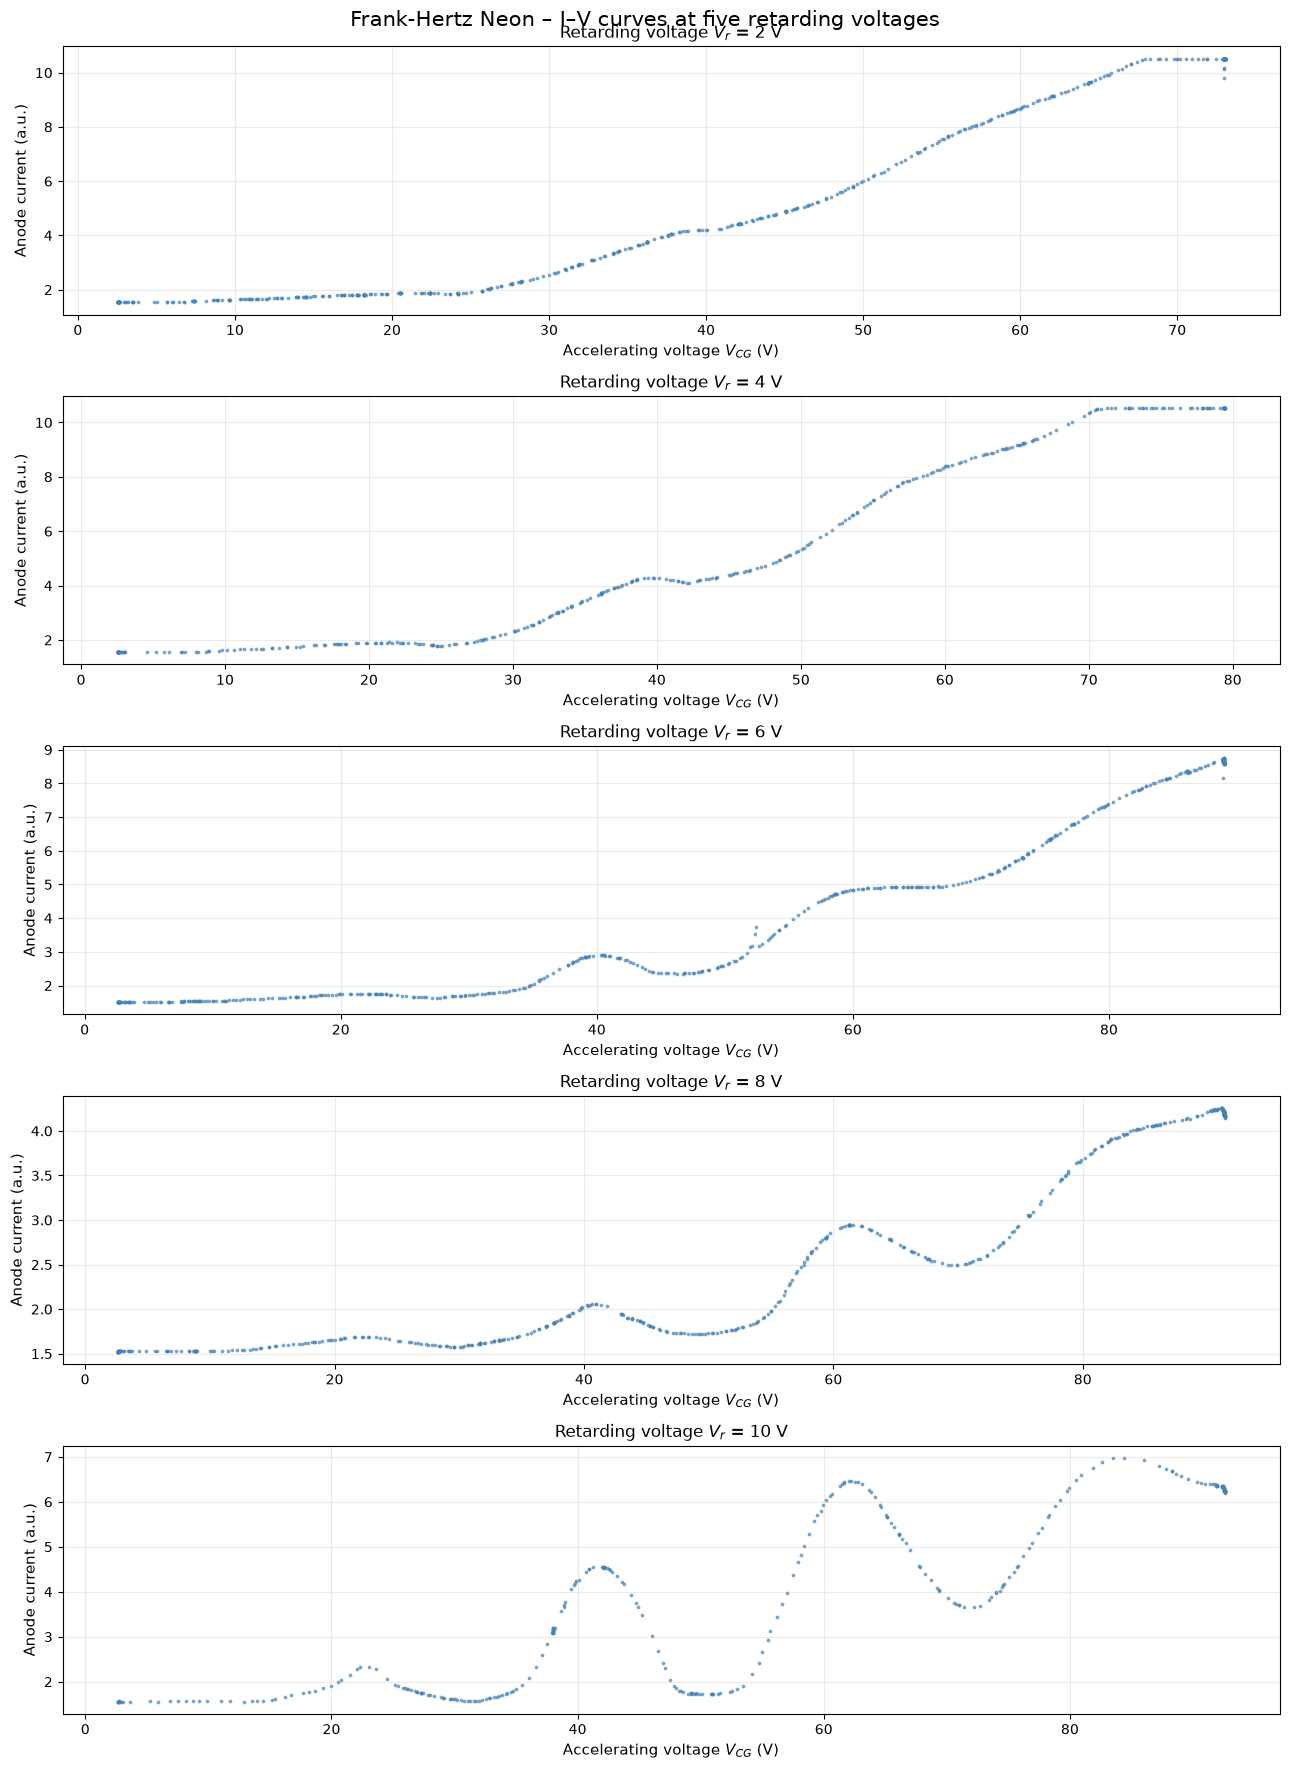

In [7]:
fig, axes = plt.subplots(5, 1, figsize=(13, 18))
fig.suptitle("Frank-Hertz Neon – I\u2013V curves at five retarding voltages", fontsize=15)

for ax, (vr, df) in zip(axes, sorted(measurements.items())):
    ax.scatter(df['voltage'], df['current'], s=3, c='steelblue', alpha=0.6)
    ax.set_xlabel("Accelerating voltage $V_{CG}$ (V)", fontsize=11)
    ax.set_ylabel("Anode current (a.u.)", fontsize=11)
    ax.set_title(f"Retarding voltage $V_r$ = {vr} V", fontsize=12)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

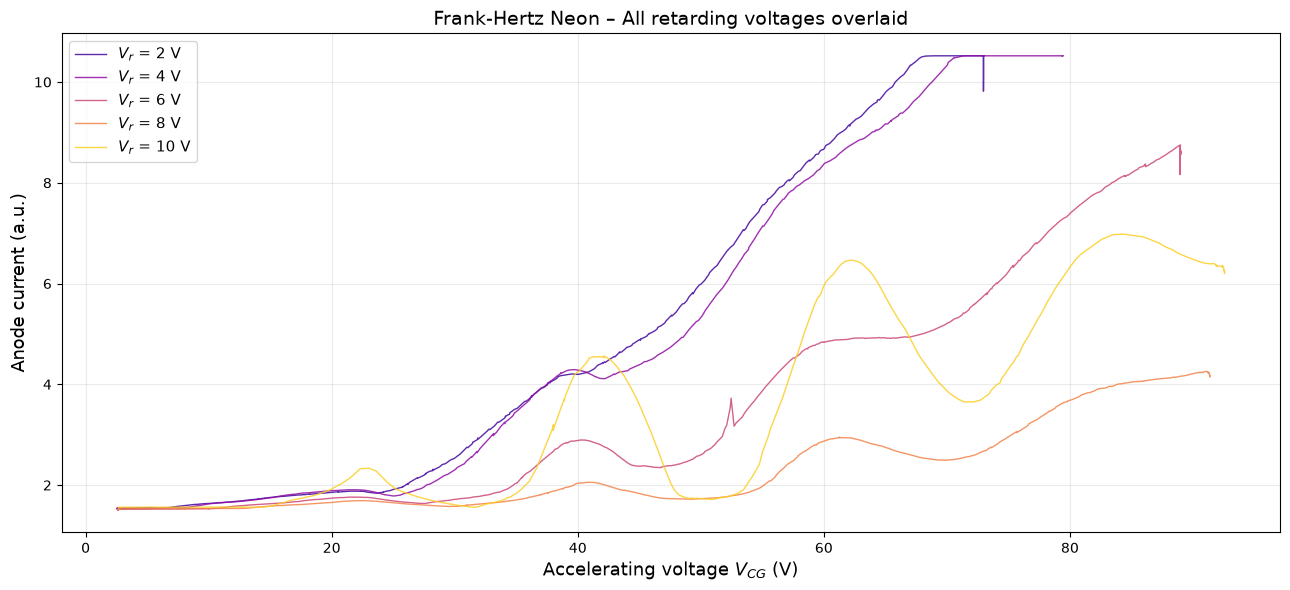

In [8]:
# All five measurements overlaid for direct comparison
fig, ax = plt.subplots(figsize=(13, 6))
colors_vr = plt.cm.plasma(np.linspace(0.1, 0.9, 5))

for color, (vr, df) in zip(colors_vr, sorted(measurements.items())):
    ax.plot(df['voltage'], df['current'], lw=1.0, alpha=0.85,
            color=color, label=f"$V_r$ = {vr} V")

ax.set_xlabel("Accelerating voltage $V_{CG}$ (V)", fontsize=13)
ax.set_ylabel("Anode current (a.u.)", fontsize=13)
ax.set_title("Frank-Hertz Neon – All retarding voltages overlaid", fontsize=14)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Measurement Selection

A good measurement for detailed analysis should:
1. Show **as many clearly resolved valley minima as possible** across the full voltage range.
2. Have **well-behaved parabolic valleys** — quantified by $\chi^2/\text{ndof}$ close to 1 for the
   parabolic fit at each minimum.

We rank each measurement by the number of valleys successfully fitted, breaking ties by the mean
$|\chi^2/\text{ndof} - 1|$ (lower = better). The winner is selected automatically; override
`best_vr` in the cell below if you prefer a different choice.

In [9]:
# Auto-detect valley positions per measurement using smoothed signal.
# No external amplifier gain for neon.
MULTIPLIER = 1

selection_results = {}
print(f"{'V_r':>5}  {'valleys found':>13}  {'mean |chi2/ndof-1|':>18}  {'dI (a.u.)':>10}")
print('-' * 55)

for vr, df in sorted(measurements.items()):
    dI = calculate_dI(df, MULTIPLIER, dead_zone_start=3, dead_zone_end=12)
    valley_centers = find_valley_centers(df)
    n_found, chi2_devs = 0, []
    for vc in valley_centers:
        m, bs, be = get_best_fit(df, vc - 12, vc + 12, dI, MULTIPLIER,
                                  min_margin=1.5, max_half_width=9.0, min_pts=8,
                                  v_center=vc)
        if m is not None:
            n_pts = len(get_points_between_voltages(df, bs, be))
            chi2_ndof = m.fval / max(n_pts - m.nfit, 1)
            chi2_devs.append(abs(chi2_ndof - 1))
            n_found += 1
    mean_dev = np.mean(chi2_devs) if chi2_devs else np.inf
    selection_results[vr] = dict(n_valleys=n_found, mean_chi2_dev=mean_dev, dI=dI,
                                  valley_centers=valley_centers)
    print(f"{vr:>4} V  {n_found:>13d}  {mean_dev:>18.3f}  {dI:>10.4f}")

# Best: most valleys resolved; ties broken by lowest mean chi2/ndof deviation
best_vr = max(selection_results,
              key=lambda vr: (selection_results[vr]['n_valleys'],
                              -selection_results[vr]['mean_chi2_dev']))
print()
print(f"→ Selected best measurement: V_r = {best_vr} V")
print("  (Override: set  best_vr = <retarding voltage>  in the next cell)")


  V_r  valleys found  mean |chi2/ndof-1|   dI (a.u.)
-------------------------------------------------------


   2 V              1              12.212      0.0456


   4 V              2              20.914      0.0420


   6 V              2              24.358      0.0116


   8 V              3              23.688      0.0024


  10 V              3              23.416      0.0016

→ Selected best measurement: V_r = 10 V
  (Override: set  best_vr = <retarding voltage>  in the next cell)


### Analysis of Best Measurement

In [10]:
# ── Override here if needed ──────────────────────────────────────
# best_vr = 4
# ────────────────────────────────────────────────────────────────

best_df  = measurements[best_vr]
dI_best  = selection_results[best_vr]['dI']

print(f"Analysing: V_r = {best_vr} V   |   dI = {dI_best:.4f} a.u.")

Analysing: V_r = 10 V   |   dI = 0.0016 a.u.


#### Valley Minima (Parabolic Fits)

In [11]:
def fit_all_valleys_ne(vi_df, dI, multiplier, label, valley_centers=None):
    print('=' * 62)
    print(f'  {label}')
    print('=' * 62)
    if valley_centers is None:
        valley_centers = find_valley_centers(vi_df)
    results = []
    for i, vc in enumerate(valley_centers):
        m, bs, be = get_best_fit(vi_df, vc - 12, vc + 12, dI, multiplier,
                                  min_margin=1.5, max_half_width=9.0, min_pts=8,
                                  v_center=vc)
        if m is None:
            print(f'  Valley {i+1}: fit failed (center ~{vc:.1f} V)')
            continue
        v0        = m.values['v0']
        v0_err    = m.errors['v0']
        c         = m.values['c']
        c_err     = m.errors['c']
        n_pts     = len(get_points_between_voltages(vi_df, bs, be))
        chi2_ndof = m.fval / max(n_pts - m.nfit, 1)
        print(f'  Valley {i+1}: v0 = {v0:.3f} +/- {v0_err:.3f} V  '
              f'| range [{bs:.2f}, {be:.2f}] V  '
              f'| chi2/ndof = {chi2_ndof:.3f}  ({n_pts} pts)')
        results.append(dict(valley=i+1, v0=v0, v0_err=v0_err,
                            c=c, c_err=c_err,
                            best_start=bs, best_end=be,
                            chi2_ndof=chi2_ndof))
    df_out = pd.DataFrame(results)
    if len(df_out) > 1:
        df_out['delta_v0']     = df_out['v0'].diff()
        df_out['delta_v0_err'] = np.sqrt(df_out['v0_err']**2 + df_out['v0_err'].shift(1)**2)
    return df_out

minima_best = fit_all_valleys_ne(
    best_df, dI_best, MULTIPLIER,
    label=f'Experiment 4 – Neon  (V_r = {best_vr} V)',
    valley_centers=selection_results[best_vr]['valley_centers'])

print()
print('--- Valley minima ---')
cols = ['valley', 'v0', 'v0_err', 'chi2_ndof']
if 'delta_v0' in minima_best.columns:
    cols += ['delta_v0', 'delta_v0_err']
print(minima_best[cols].to_string(index=False))


  Experiment 4 – Neon  (V_r = 10 V)


  Valley 1: v0 = 31.204 +/- 0.013 V  | range [29.73, 32.79] V  | chi2/ndof = 25.373  (14 pts)


  Valley 2: v0 = 51.884 +/- 0.023 V  | range [49.84, 53.45] V  | chi2/ndof = 24.699  (12 pts)


  Valley 3: v0 = 71.231 +/- 0.026 V  | range [69.38, 72.72] V  | chi2/ndof = 23.176  (9 pts)

--- Valley minima ---
 valley        v0   v0_err  chi2_ndof  delta_v0  delta_v0_err
      1 31.204058 0.012600  25.373051       NaN           NaN
      2 51.884204 0.023159  24.699062 20.680146      0.026365
      3 71.231361 0.025760  23.175899 19.347157      0.034640


#### Current Maxima (Light Fringe Positions)

In [12]:
# Peak (maximum) search brackets — each bracket should contain exactly one peak.
# We locate maxima by fitting a parabola to the negated current (turning a maximum into a minimum).
peak_ranges_ne = [
    ( 5, 24),   # peak before valley 1
    (28, 45),   # peak between valley 1 and 2
    (47, 63),   # peak between valley 2 and 3
    (65, 80),   # peak between valley 3 and 4
]

def find_maxima_ne(vi_df, dI, multiplier):
    """Locate current maxima by fitting a parabola to the negated current."""
    neg_df = vi_df.copy()
    neg_df['current'] = -neg_df['current']  # flip so maxima become minima
    results = []
    for i, (v_start, v_end) in enumerate(peak_ranges_ne):
        m, bs, be = get_best_fit(neg_df, v_start, v_end, dI, multiplier,
                                  min_margin=1.0, max_half_width=5.0, min_pts=6)
        if m is None:
            print(f"  Peak {i+1}: fit failed")
            continue
        v0      = m.values['v0']
        v0_err  = m.errors['v0']
        n_pts   = len(get_points_between_voltages(vi_df, bs, be))
        chi2_ndof = m.fval / max(n_pts - m.nfit, 1)
        print(f"  Peak {i+1}: v0 = {v0:.3f} \u00b1 {v0_err:.3f} V  "
              f"| range [{bs:.2f}, {be:.2f}] V  "
              f"| \u03c7\u00b2/ndof = {chi2_ndof:.3f}  ({n_pts} pts)")
        results.append(dict(peak=i+1, v0=v0, v0_err=v0_err,
                            best_start=bs, best_end=be))
    return pd.DataFrame(results)

print(f"Current maxima (light fringe positions) for V_r = {best_vr} V:")
maxima_best = find_maxima_ne(best_df, dI_best, MULTIPLIER)

print("\n--- Current maxima ---")
print(maxima_best[['peak', 'v0', 'v0_err']].to_string(index=False))

Current maxima (light fringe positions) for V_r = 10 V:
  Peak 1: fit failed


  Peak 2: v0 = 42.068 ± 0.012 V  | range [40.89, 43.22] V  | χ²/ndof = 8.750  (14 pts)
  Peak 3: fit failed
  Peak 4: fit failed

--- Current maxima ---
 peak        v0   v0_err
    2 42.068099 0.011765


#### Visualization: Data with Parabolic Fits

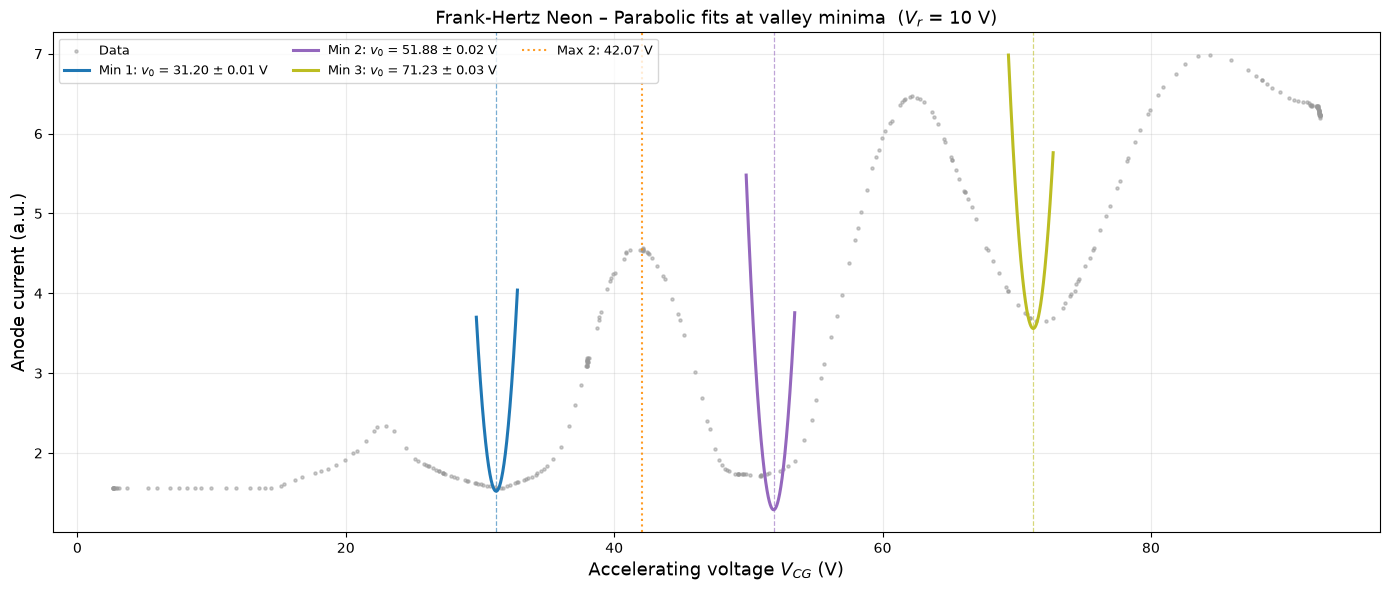

In [13]:
n_valleys  = len(minima_best)
colors_val = plt.cm.tab10(np.linspace(0, 0.85, max(n_valleys, 1)))

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title(
    f"Frank-Hertz Neon \u2013 Parabolic fits at valley minima  ($V_r$ = {best_vr} V)",
    fontsize=13)

# Raw data
ax.scatter(best_df['voltage'], best_df['current'] * MULTIPLIER,
           s=5, c='#999999', alpha=0.5, zorder=1, label='Data')

# Parabolic fits at minima
for _, row in minima_best.iterrows():
    idx   = int(row['valley']) - 1
    color = colors_val[idx]
    v_fit = np.linspace(row['best_start'], row['best_end'], 500)
    I_fit = (v_fit - row['v0'])**2 + row['c']
    ax.plot(v_fit, I_fit, color=color, linewidth=2.2, zorder=3,
            label=f"Min {int(row['valley'])}: $v_0$ = {row['v0']:.2f} \u00b1 {row['v0_err']:.2f} V")
    ax.axvline(row['v0'], color=color, linestyle='--', linewidth=0.9, alpha=0.6, zorder=2)

# Maxima markers (light fringe positions)
for _, row in maxima_best.iterrows():
    ax.axvline(row['v0'], color='darkorange', linestyle=':', linewidth=1.5, alpha=0.85,
               label=f"Max {int(row['peak'])}: {row['v0']:.2f} V")

ax.set_xlabel("Accelerating voltage $V_{CG}$ (V)", fontsize=13)
ax.set_ylabel("Anode current (a.u.)", fontsize=13)
ax.legend(fontsize=9, ncol=3, loc='upper left')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Linear Fit: Excitation Energy of Neon

The positions of successive valley minima follow $v_N = a \cdot N + b$,
where the slope $a$ equals the first excitation energy $\Delta E$ of neon (in eV)
and the offset $b$ encodes the contact potential plus the retarding voltage.

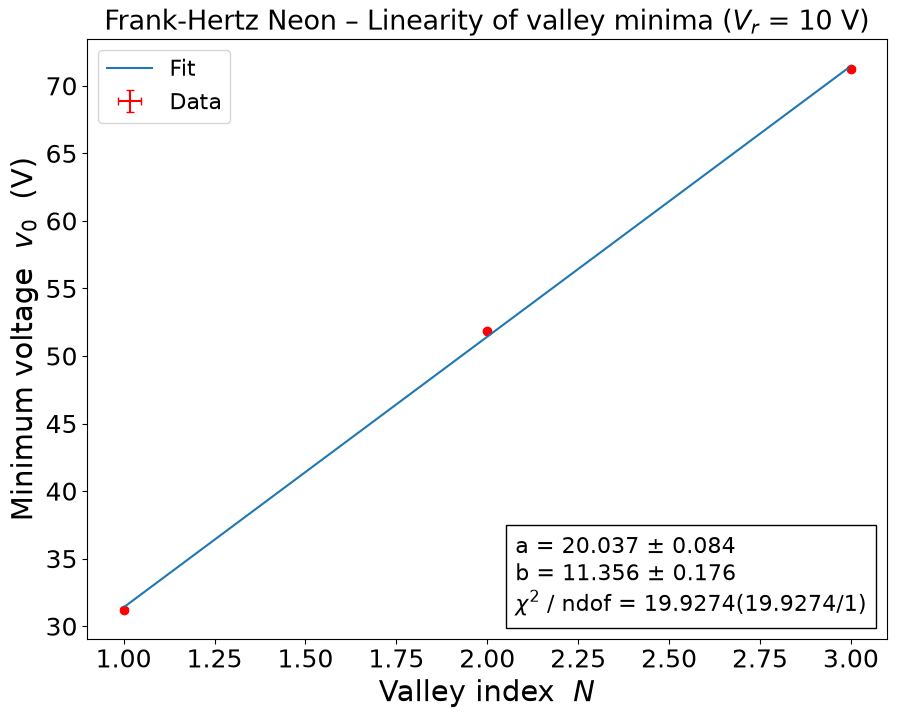


  Excitation energy  ΔE = 20.037 ± 0.084 eV
  Offset             b  = 11.356 ± 0.176 V
  Literature value   ΔE = 18.7 eV
  Relative deviation     = 7.2 %


In [14]:
linear_minima = lambda N, a, b: a * N + b

N   = minima_best['valley'].to_numpy(dtype=float)
v0  = minima_best['v0'].to_numpy()
dv0 = (minima_best['v0_err'] + 0.1).to_numpy()  # add 0.1 V digitisation floor

reg  = Chi2Reg(linear_minima, N, v0, dy=dv0)
mopt = Minuit(reg, a=18.7, b=5.0)
mopt.migrad()

reg.show(mopt,
         x_title="Valley index  $N$",
         y_title="Minimum voltage  $v_0$  (V)",
         plot_title=f"Frank-Hertz Neon \u2013 Linearity of valley minima ($V_r$ = {best_vr} V)",
         goodness_loc=4,
         metric="chi2")
plt.show()

DE_measured = mopt.values['a']
DE_err      = mopt.errors['a']
b_offset    = mopt.values['b']
b_err       = mopt.errors['b']
DE_lit      = 18.7  # eV — accepted spacing in the Ne Frank-Hertz experiment

print(f"\n  Excitation energy  \u0394E = {DE_measured:.3f} \u00b1 {DE_err:.3f} eV")
print(f"  Offset             b  = {b_offset:.3f} \u00b1 {b_err:.3f} V")
print(f"  Literature value   \u0394E = {DE_lit:.1f} eV")
print(f"  Relative deviation     = {100*abs(DE_measured - DE_lit)/DE_lit:.1f} %")

### Results and Discussion

| Quantity | Value |
|---|---|
| Gas | Neon (Ne) |
| Best retarding voltage $V_r$ | — |
| Valley minima resolved | — |
| Measured excitation energy $\Delta E$ | — eV |
| Literature value | 18.7 eV |

*(Fill in the table from the cell output above.)*

---

#### Light Fringes

The glowing orange bands visible in the neon tube are produced where electrons have accumulated
exactly enough kinetic energy to excite neon atoms inelastically.
Each excited atom quickly de-excites from the $2p^5 3p$ states to the $2p^5 3s$ states,
emitting photons in the 590–670 nm (orange–red) range.

- **Number of fringes**: determined by how many complete excitation zones fit between cathode and
  anode. With $N$ valley minima observed there are $N-1$ light-emitting zones between them,
  plus a partial zone before the first valley. The number of clearly visible fringes
  therefore equals the number of resolved maxima listed above.

- **Positions of fringes**: correspond to the current **maxima** — the regions where the electron
  population carrying enough energy for inelastic collisions is largest. As $V_r$ increases,
  all fringes shift toward higher $V_{CG}$ because electrons must do extra work against the
  retarding field before reaching the anode.

#### Why only one excitation energy?

Although neon has many excited states, the Frank-Hertz experiment shows a single dominant
periodicity at $\approx 18.7$ eV because:

1. The $2p^5 3p$ state group (at $\approx 18.4$–$18.7$ eV) has the largest electron-impact
   excitation cross-section in this energy range.
2. Lower-lying states (the metastable $2p^5 3s$ levels at $\approx 16.6$ eV) have a smaller
   cross-section and do not produce a comparably clear periodic signal.
3. Higher excited states require energies well above 18.7 eV and become relevant only at
   correspondingly higher accelerating voltages.